### 릿지(Ridge)
- 최소제곱 적합식의 수축 패널티라 불리는 항에 L2L 패널티를 추가한것

- paramater
    - alpha
        - 기본값 : 1.0
        - 규제의 강도 -> 클수록 회귀 계수가 작아지고 과대적합을 방지, 과소적합 위험
    - solver
        - 기본값 : 'auto'
        - 데이터의 크기 / 희소성에 따라 적합한 solver를 선택
        - 'cholesky' : 콜레스키 분해, 가장 기본적인 수식, 데이터의 개수가 작거나 중간 정도
        - 'svd' : 특이값 분해, 다중공선성이 있는 경우에 조금 더 안정적으로 계산, 데이터의 개수가 작거나 중간 정도
        - 'sparse_cg', 'lspr' : 공액 기울기법 (0인 데이터를 무시하고 계산), 대규모 데이터중 희소 데이터
        - 'sag' : 확률적 평균 검사 (기존의 기울기만이 아니라 과거의 기울기의 평균을 이용하여 가중치 변화), 데이터의
        행의 개수가 열의 개수보다 월등히 많은 경우
        - 'saga' : sag 확장, 대규모 희소 데이터가 존재하는 경우, ElasticNet에서 사용
    - tol
        - 기본값 : 0.001 (1e-03)
        - 수렴의 판단 기준. 작을수록 정밀, 속도면에서는 느려질수 있다.
    - max_iter
        - 기본값 : None
        - 최적화가 될때까지 최대 반복 횟수
        - 데이터가 크거나 수치가 불안정한 경우에 필요
- 속성
    - n_iter_
        - solver가 반복한 횟수를 입력
    - coef_
        - 회귀 계수를 출력 (규제로 인한 가중치의 감소량 때문에 선형회귀보다는 낮은 값들이 출력)


In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.linear_model import Ridge
import matplotlib.pyplot as plt

In [2]:
# 데이터셋 로드
diabetes = load_diabetes()

In [3]:
diabetes

{'data': array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
          0.01990749, -0.01764613],
        [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
         -0.06833155, -0.09220405],
        [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
          0.00286131, -0.02593034],
        ...,
        [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
         -0.04688253,  0.01549073],
        [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
          0.04452873, -0.02593034],
        [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
         -0.00422151,  0.00306441]], shape=(442, 10)),
 'target': array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
         69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
         68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
         87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
        259.,  53., 190., 142.,  75., 142.

In [4]:
diabetes.frame

In [5]:
df = pd.DataFrame(diabetes['data'], columns = diabetes['feature_names'])

In [6]:
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [7]:
# 알파 -> 규제의 강도 1e-03, 1e-02, 1e-01, 1e+00, 1e+01
# numpydp logspace() 함수를 이용해서 데이터를 생성
alphas = np.logspace(-3, 1, 5)
alphas

array([1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01])

In [8]:
# alpha 값에 따른 회귀 계수를 파악
data = []

for a in alphas:
    # 모델 생성
    ridge = Ridge(alpha = a)
    # 모델 학습
    ridge.fit(diabetes['data'], diabetes['target'])
    # 학습이 된 모델에서 회귀계수를 data 빈 리스트에 추가
    data.append(
        ridge.coef_
    )
data

[array([  -9.54916175, -239.08695779,  520.3693746 ,  323.82274522,
        -712.32215918,  413.37912498,   65.81132269,  167.51300694,
         720.9399241 ,   68.12336029]),
 array([  -7.19753448, -234.54976419,  520.58860098,  320.51713055,
        -380.6071353 ,  150.48467052,  -78.58927534,  130.31252148,
         592.34795865,   71.13484405]),
 array([   1.30870543, -207.19241786,  489.69517109,  301.76405786,
         -83.46603399,  -70.8268319 , -188.67889782,  115.7121356 ,
         443.81291747,   86.7493154 ]),
 array([  29.46611189,  -83.15427636,  306.35268015,  201.62773437,
           5.90961437,  -29.51549508, -152.04028006,  117.3117316 ,
         262.94429001,  111.87895644]),
 array([ 19.81284181,  -0.91842974,  75.41621398,  55.02515953,
         19.92462111,  13.94871542, -47.5538158 ,  48.2594332 ,
         70.14394833,  44.21389238])]

In [9]:
df_ridge = pd.DataFrame(
    data, index = alphas, columns = df.columns
)
df_ridge

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0.001,-9.549162,-239.086958,520.369375,323.822745,-712.322159,413.379125,65.811323,167.513007,720.939924,68.123360
0.010,-7.197534,-234.549764,520.588601,320.517131,-380.607135,150.484671,-78.589275,130.312521,592.347959,71.134844
0.100,1.308705,-207.192418,489.695171,301.764058,-83.466034,-70.826832,-188.678898,115.712136,443.812917,86.749315
1.000,29.466112,-83.154276,306.352680,201.627734,5.909614,-29.515495,-152.040280,117.311732,262.944290,111.878956
10.000,19.812842,-0.918430,75.416214,55.025160,19.924621,13.948715,-47.553816,48.259433,70.143948,44.213892


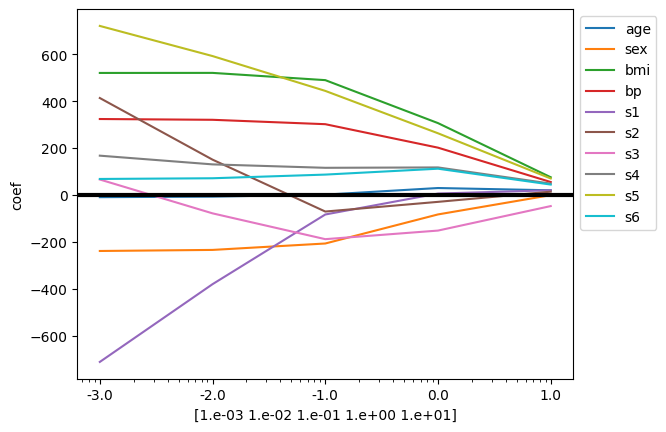

In [10]:
plt.semilogx(df_ridge)

plt.xticks(alphas, labels = np.log10(alphas))

plt.legend(labels = df_ridge.columns, bbox_to_anchor = (1, 1))
plt.xlabel(alphas)
plt.ylabel('coef')
plt.axhline(y = 0, color = 'black', linewidth = 3)

plt.show()

In [11]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(diabetes['data'], diabetes['target'])

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


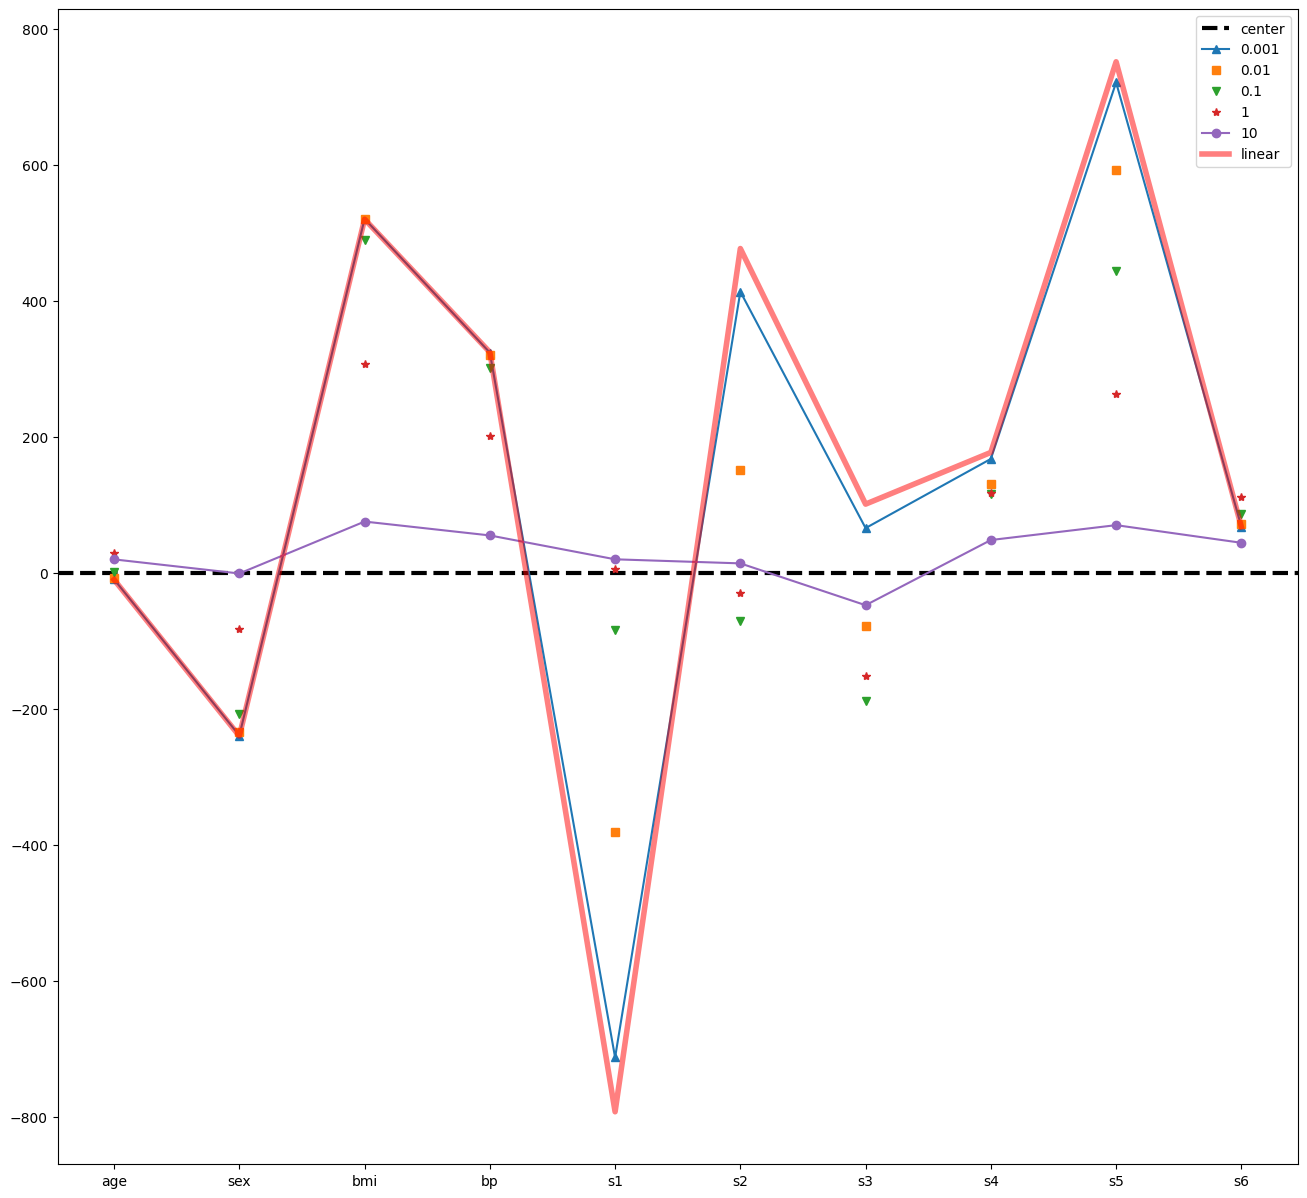

In [12]:
plt.figure(figsize = (16, 15))
plt.axhline(y = 0, linestyle = '--', linewidth = 3, color = 'black')

plt.plot(df_ridge.loc[0.001, ], '^-')
plt.plot(df_ridge.loc[0.01, ], 's')
plt.plot(df_ridge.loc[0.1, ], 'v')
plt.plot(df_ridge.loc[1.0, ], '*')
plt.plot(df_ridge.loc[10.0, ], 'o-')
plt.plot(lr.coef_, 'r', linewidth = 4, alpha = 0.5)

plt.legend( ['center', 0.001, 0.01, 0.1, 1, 10, 'linear'], bbox_to_anchor = (1, 1))
plt.show()

- 연습
    - 당뇨병 데이터를 이용하여 위험 지수를 예측
    - train, test는 8:2 비율로 나눠주고
    - 선형회귀의 방법으로 mae의 값을 이용하여 성능을 확인
    - 릿지에서 알파 값을 0.01, 0.1, 1인 경우로 모델을 생성하고 학습 뒤 예측하고 mae의 값을 확인
    - 가장 성능이 좋은 모델은 무엇인가?

In [13]:
from sklearn.model_selection import train_test_split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    diabetes['data'], diabetes['target'], test_size=0.2, random_state=42
)

In [15]:
lr  = LinearRegression()
ridge_1 = Ridge(alpha = 0.01)
ridge_2 = Ridge(alpha = 0.1)
ridge_3 = Ridge(alpha = 1)

In [16]:
# 각각의 모델에 학습
lr.fit(X_train, y_train)
ridge_1.fit(X_train, y_train)
ridge_2.fit(X_train, y_train)
ridge_3.fit(X_train, y_train)

,alpha,1
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [17]:
# 각각의 모델을 이용하여 예측
pred_lr = lr.predict(X_test)
pred_1 = ridge_1.predict(X_test)
pred_2 = ridge_2.predict(X_test)
pred_3 = ridge_3.predict(X_test)

In [18]:
from sklearn.metrics import mean_absolute_error, r2_score

In [19]:
print(round(mean_absolute_error(y_test, pred_lr), 4))
print(round(mean_absolute_error(y_test, pred_1), 4))
print(round(mean_absolute_error(y_test, pred_2), 4))
print(round(mean_absolute_error(y_test, pred_3), 4))

42.7941
42.8369
42.9969
46.1389


In [20]:
print(round(r2_score(y_test, pred_lr), 4))
print(round(r2_score(y_test, pred_1), 4))
print(round(r2_score(y_test, pred_2), 4))
print(round(r2_score(y_test, pred_3), 4))

0.4526
0.456
0.4609
0.4192


In [21]:
# 가중치 * 입력값 + 절편 --> 예측값

# 가중치(회귀 계수)
w_list = ridge_3.coef_

w_list

array([  45.36737726,  -76.66608563,  291.33883165,  198.99581745,
         -0.53030959,  -28.57704987, -144.51190505,  119.26006559,
        230.22160832,  112.14983004])

In [22]:
# 입력값 X_test
x_list = X_test[0]
x_list

array([ 0.04534098, -0.04464164, -0.00620595, -0.01599898,  0.1250187 ,
        0.1251981 ,  0.019187  ,  0.03430886,  0.03243232, -0.0052198 ])

In [23]:
# 절편 값 
b = ridge_3.intercept_
b

np.float64(152.241675211113)

In [24]:
b_1 = b

for i in range(len(x_list)):
    b_1 += w_list[i] * x_list[i]

b_1

np.float64(157.28546957818568)

In [25]:
pred_3[0]

np.float64(157.28546957818565)

In [26]:
for w, x in zip(w_list, x_list):
    # print(w)
    # print(x)
    b += w * x
b

np.float64(157.28546957818568)

In [27]:
list(zip(w_list, x_list))

[(np.float64(45.36737725644653), np.float64(0.04534098333546186)),
 (np.float64(-76.66608563426297), np.float64(-0.044641636506989144)),
 (np.float64(291.33883165003607), np.float64(-0.006205954135807083)),
 (np.float64(198.99581744683996), np.float64(-0.015998975220305175)),
 (np.float64(-0.530309590104964), np.float64(0.12501870313429186)),
 (np.float64(-28.577049867710777), np.float64(0.1251981011367534)),
 (np.float64(-144.51190505457356), np.float64(0.019186997017453092)),
 (np.float64(119.26006559078789), np.float64(0.03430885887772673)),
 (np.float64(230.22160832411993), np.float64(0.03243232415655107)),
 (np.float64(112.14983003850017), np.float64(-0.005219804415300423))]

### 라쏘(Lasso)

- 선형 회귀에서 L1 패널티를 추가한 방법
- parameter
    - alpha
        - 기본값 : 1.0
        - 규제의 강도
        - 규제가 강도가 너무 큰 경우에는 많은 컬럼의 회귀 계수가 0이 되어 모델이 단순화(과소적합)
        - 적절한 규제 강도를 사용시 회귀 계수가 0인 되는 컬럼들이 발생하면서 자동적으로 feature select(불필요한 컬럼 제거)
    - selection
        - 기본값 : 'cyclic'
        - 좌표축 경사법의 업데이트의 순서
            - 'cyclic' : 순차적으로 업데이트
            - 'random' : 무작위 선택 업데이트
    - percompute
        - 기본값 : 'auto'
        - 인자값은 bool
        - 그람행렬을 계산하고 메모리에 저장할것인가?
        - 피쳐의 개수가 너무 많은 경우라면 False을 사용하고 개수가 적다면 True
    - warm_start
        - 기본값 : False
        - 이전의 학습 결과를 기억 할것인가?

In [28]:
from sklearn.linear_model import Lasso

In [29]:
alpha = np.logspace(-3, 1, 5)
data = []

for a in alpha:
    lasso = Lasso(alpha=a)

    lasso.fit(diabetes['data'], diabetes['target'])
    data.append(lasso.coef_)

lasso_df = pd.DataFrame(data, index = alpha, columns = df.columns)
lasso_df

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0.001,-8.996177,-238.896328,520.267403,323.423596,-720.244828,421.399753,66.733503,164.448022,725.335558,67.476810
0.010,-1.304662,-228.819129,525.566130,316.168834,-307.016211,89.324647,-105.078369,119.597616,571.330356,65.008383
0.100,-0.000000,-155.359976,517.186795,275.077235,-52.539365,-0.000000,-210.157991,0.000000,483.912648,33.673965
1.000,0.000000,-0.000000,367.703860,6.298858,0.000000,0.000000,-0.000000,0.000000,307.605418,0.000000
10.000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.000000,0.000000,0.000000,0.000000


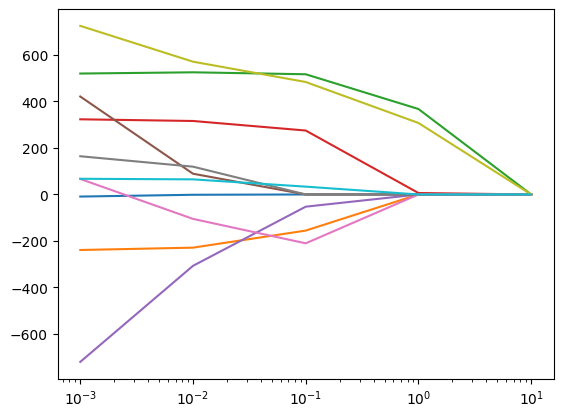

In [30]:
plt.semilogx(lasso_df)

plt.show()

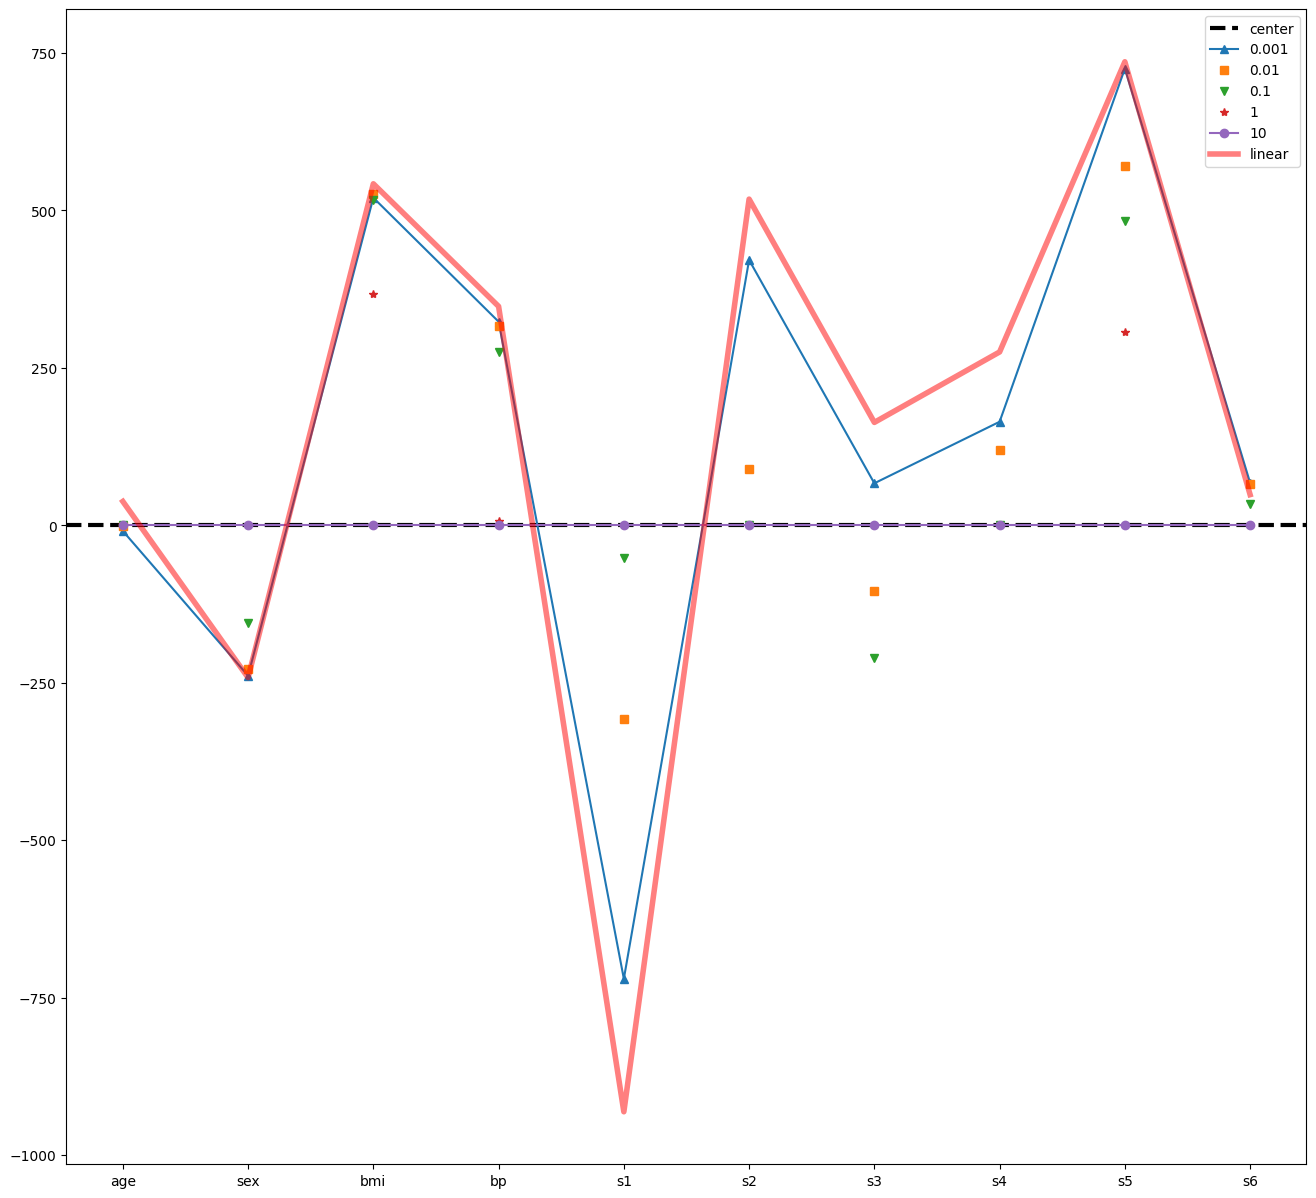

In [31]:
plt.figure(figsize=(16, 15))
plt.axhline(y= 0, linestyle='--', linewidth = 3, color='black')

plt.plot(lasso_df.loc[0.001, ], '^-')
plt.plot(lasso_df.loc[0.01, ], 's')
plt.plot(lasso_df.loc[0.1, ], 'v')
plt.plot(lasso_df.loc[1.0, ], '*')
plt.plot(lasso_df.loc[10.0, ], 'o-')
plt.plot(lr.coef_, 'r', linewidth = 4, alpha = 0.5)

plt.legend( ['center', 0.001, 0.01, 0.1, 1, 10, 'linear'], bbox_to_anchor = (1, 1) )

plt.show()

In [32]:
# 규제 강도에 따라서 mae, r2score를 확인 
x = diabetes['data']
y = diabetes['target']

In [33]:
lasso_1 = Lasso(alpha=0.01)
lasso_2 = Lasso(alpha=0.1)
lasso_3 = Lasso(alpha=1)

In [34]:
lasso_1.fit(X_train, y_train)
lasso_2.fit(X_train, y_train)
lasso_3.fit(X_train, y_train)

,alpha,1
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [35]:
pred_1 = lasso_1.predict(X_test)
pred_2 = lasso_2.predict(X_test)
pred_3 = lasso_3.predict(X_test)

In [36]:
print( mean_absolute_error(y_test, pred_1) )
print( mean_absolute_error(y_test, pred_2) )
print( mean_absolute_error(y_test, pred_3) )

42.831847073360876
42.85442771664998
49.73032753662261


In [37]:
print( r2_score(y_test, pred_1) )
print( r2_score(y_test, pred_2) )
print( r2_score(y_test, pred_3) )

0.45668611945806237
0.4718547867276227
0.3575918767219115


In [38]:
lasso_4 = Lasso(alpha=10)

lasso_4.fit(X_train, y_train)

lasso_4.predict(X_test)

array([153.73654391, 153.73654391, 153.73654391, 153.73654391,
       153.73654391, 153.73654391, 153.73654391, 153.73654391,
       153.73654391, 153.73654391, 153.73654391, 153.73654391,
       153.73654391, 153.73654391, 153.73654391, 153.73654391,
       153.73654391, 153.73654391, 153.73654391, 153.73654391,
       153.73654391, 153.73654391, 153.73654391, 153.73654391,
       153.73654391, 153.73654391, 153.73654391, 153.73654391,
       153.73654391, 153.73654391, 153.73654391, 153.73654391,
       153.73654391, 153.73654391, 153.73654391, 153.73654391,
       153.73654391, 153.73654391, 153.73654391, 153.73654391,
       153.73654391, 153.73654391, 153.73654391, 153.73654391,
       153.73654391, 153.73654391, 153.73654391, 153.73654391,
       153.73654391, 153.73654391, 153.73654391, 153.73654391,
       153.73654391, 153.73654391, 153.73654391, 153.73654391,
       153.73654391, 153.73654391, 153.73654391, 153.73654391,
       153.73654391, 153.73654391, 153.73654391, 153.73

In [39]:
from sklearn.preprocessing import PolynomialFeatures

In [40]:
# 다항 회귀 데이터셋 추가 
poly = PolynomialFeatures(degree=3)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [41]:
X_train_poly.shape

(353, 286)

In [42]:
lasso_1.fit(X_train_poly, y_train)
lasso_2.fit(X_train_poly, y_train)
lasso_3.fit(X_train_poly, y_train)

,alpha,1
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [43]:
pred_1 = lasso_1.predict(X_test_poly)
pred_2 = lasso_2.predict(X_test_poly)
pred_3 = lasso_3.predict(X_test_poly)

In [44]:
print( r2_score(y_test, pred_1) )
print( r2_score(y_test, pred_2) )
print( r2_score(y_test, pred_3) )

0.49076078413751045
0.4718547867276227
0.3575918767219115


### 엘라스틱넷 (ElasticNet)
- 릿지 회귀, 라쏘 회귀를 절충한 알고리즘
- L1, L2 패널티를 혼합하여 사용 -> 매개변수에서 혼합의 비율
- parameter
    - alpha
        - 기본값 : 1.0
        - 규제의 강도 (L1, L2 모두 포함)
    - l1_ratio
        - 기본값 : 0.5
        - L1 패널티의 비중
        - 0 : 릿지 회귀
        - 1 : 라쏘 회귀
        - 0에서 1 사잇값 : 엘라스틱넷

In [45]:
from sklearn.linear_model import ElasticNet

In [46]:
data = []

for a in alpha:
    ela = ElasticNet(alpha = a)

    ela.fit(x, y)
    data.append(ela.coef_)

ela_df = pd.DataFrame(data, index = alpha, columns = df.columns)

In [47]:
ela_df

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0.001,8.706329,-178.074465,450.884335,281.068431,-44.049705,-77.943898,-188.957481,119.794399,393.702359,98.944302
0.010,33.147367,-35.245354,211.024367,144.559236,21.931722,0.000000,-115.619973,100.658917,185.325911,96.257335
0.100,10.286332,0.285983,37.464655,27.544765,11.108856,8.355892,-24.120809,25.505492,35.465700,22.894985
1.000,0.359018,0.000000,3.259767,2.204340,0.528646,0.250935,-1.861363,2.114454,3.105835,1.769851
10.000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.000000,0.000000,0.000000,0.000000


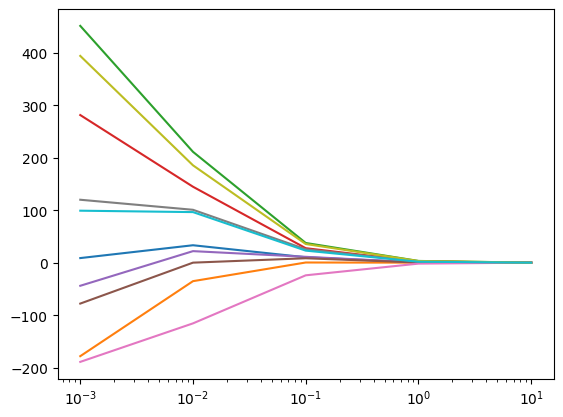

In [48]:
plt.semilogx(ela_df)

plt.show()

In [49]:
ela_1 = ElasticNet(alpha=0.01)
ela_2 = ElasticNet(alpha=0.1)
ela_3 = ElasticNet(alpha=1)

In [50]:
ela_1.fit(X_train, y_train)
ela_2.fit(X_train, y_train)
ela_3.fit(X_train, y_train)

,alpha,1
,l1_ratio,0.5
,fit_intercept,True
,precompute,False
,max_iter,1000
,copy_X,True
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [51]:
pred_1 = ela_1.predict(X_test)
pred_2 = ela_2.predict(X_test)
pred_3 = ela_3.predict(X_test)

In [52]:
print(r2_score(y_test, pred_1))
print(r2_score(y_test, pred_2))
print(r2_score(y_test, pred_3))

0.37364841571505814
0.09865421116113748
-0.0024652131111431164


#### 연습 문제

- 데이터 수집
    - sklearn 안에 샘플 데이터셋 중 fetch_cailfornia_housing 데이터셋을 로드
    - 샘플 데이터를 이용하여 독립 변수, 종속 변수로 데이터를 각각 저장
- 데이터 튜닝
    - 학습 데이터와 검증 데이터로 7:3의 비율로 나눠준다.
- 선형 회귀 모델과, 엘라스틱넷을 모델을 생성
    - alpha : 0.01, 0.1, 1
    - l1_ratio : 0, 0.5, 1
    - (반복문을 이용하여 성능 평가 | 모델의 성능 평가는 함수로 생성하고 반복문 ) 
- 각각의 모델들의 R2 Score를 확인

In [ ]:
# !pip install --upgrade scikit-learn


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [54]:
from sklearn.datasets import fetch_california_housing

In [ ]:
cali = fetch_california_housing()

In [ ]:
df = pd.DataFrame(cali['data'], columns = cali['feature_names'])

In [ ]:
df['price'] = cali['target']

In [ ]:
df.head(1)

- 캘리포니아 부동산 정보
    - MedInc : 중간 소득
    - HouseAge : 주택 연식
    - AveRooms : 평균 방의 개수
    - AveBedrms : 평균 침실의 개수
    - Population : 인구( 해당 블록의 거주하는 인구의 수 )
    - AveOccup : 평균 거주자 수
    - Latitude : 위도
    - Longitude : 경도
    - price : 주택의 중간 가격

df.describe()

In [ ]:
x = df.drop('price', axis=1).values
y = df['price'].values

In [ ]:
# 7:3 비율로 train, test로 데이터를 분할 
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=42
)

In [ ]:
def models(x1, x2, y1, y2):
    # 모델들을 생성 
    lr = LinearRegression()
    # 엘라스틱에서 사용이 되는 변수의 목록 
    alpha_list = [0.01, 0.1, 1]
    l1_list = [0, 0.5, 1]
    model_names = ['Ridge', 'Elastic', 'Lasso']
    # 각 모델들의 성능을 저장하기 위해 빈 딕셔너리 생성 
    result = {}
    # 선형 모델 학습, 예측 r2score
    lr.fit(x1, y1)
    pred_lr = lr.predict(x2)
    r2_lr = r2_score(y2, pred_lr)

    result['Linear'] = r2_lr

    for model, l1 in zip(model_names, l1_list):
        for a in alpha_list:
            # 엘라스틱넷 모델을 생성
            ela = ElasticNet(alpha=a, l1_ratio=l1)

            ela.fit(x1, y1)

            pred_ela = ela.predict(x2)
            r2_ela = r2_score(y2, pred_ela)

            result[model+str(a)] = r2_ela
    return result

In [ ]:
res = models(X_train, X_test, y_train, y_test)

In [ ]:
pd.Series(res).sort_values(ascending=False)

In [ ]:
# 극단치의 경계값을 구한다. (AveRooms)
q_1, q_3 = np.percentile( df['AveRooms'], [25, 75] )
print(q_1, q_3)

In [ ]:
iqr = q_3 - q_1

upper_whis = q_3 + (1.5 * iqr)
lower_whis = q_1 - (1.5 * iqr)

print(upper_whis, lower_whis)

In [ ]:
flag1 = df['AveRooms'] < lower_whis
flag2 = df['AveRooms'] > upper_whis

df.loc[flag1 | flag2, ]

In [ ]:
df.loc[flag2, ]

In [ ]:
df2 = df.loc[ ~( flag1 | flag2 ), ]
df2.describe()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    df2.drop('price', axis=1), 
    df2['price'], 
    test_size=0.3, 
    random_state=42
)

In [ ]:
res2 = models(X_train, X_test, y_train, y_test)

In [ ]:
pd.Series(res2).sort_values(ascending=False)

In [ ]:
# df2에 스케일링 작업을 한 뒤 모델에서 학습 
from sklearn.preprocessing import MinMaxScaler

In [ ]:
mnsclaer = MinMaxScaler()

In [ ]:
# train 데이터로 fit()
X_train_sc = mnsclaer.fit_transform(X_train)
X_test_sc = mnsclaer.transform(X_test)

In [ ]:
res_sc = models(X_train_sc, X_test_sc, y_train, y_test)

In [ ]:
pd.Series(res_sc).sort_values(ascending=False)